<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Time Series EDA Lab

---

This lab covers the exploratory toolkit you need **before** fitting any time series model. It walks through: 

- Loading and indexing a real-world time series
- Visualizing trend by resampling / rolling smoothing
- Testing for stationarity with the Augmented Dickey-Fuller (ADF) test
- Diagnosing the series using ACF and PACF plots

## About the Data

`residents.csv` contains a **quarterly resident population count**, in thousands, from **April 1971 to April 1993** (89 quarters):

| Column | Description |
|---|---|
| `date` | Quarter (month-year, e.g. `04-1971`) |
| `residents` | Resident population that quarter, in thousands |

We're going to hold the **final 8 quarters (1991–1993)** out completely. Everything in this EDA lab uses only the first **81 quarters (1971–1990)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

## Part 1 - Load and Set Aside the Holdout 

### 1. Load `residents.csv`, parse `date` as a datetime (format is `MM-YYYY`), and set it as the index.

In [2]:
# YOUR CODE HERE
df = pd.read_csv('data/residents.csv', parse_dates=['date'],date_format='%m-%Y')

In [3]:
df.head()

,date,residents
0,1971-04-01,13067.3
1,1971-07-01,13130.5
2,1971-10-01,13198.4
3,1972-01-01,13254.2
4,1972-04-01,13303.7


In [4]:
df.dtypes

date         datetime64[us]
residents           float64
dtype: object

In [5]:
df.describe()

,date,residents
count,89,89.000000
mean,1982-04-01 09:42:28.314606,15273.449438
min,1971-04-01 00:00:00,13067.300000
25%,1976-10-01 00:00:00,14110.100000
50%,1982-04-01 00:00:00,15184.200000
75%,1987-10-01 00:00:00,16398.900000
max,1993-04-01 00:00:00,17661.500000
std,NaN,1356.812524


In [6]:
df.set_index('date', inplace=True)

In [7]:
df.index = df.index.strftime('%m-%Y')

In [8]:
df.head()

,residents
date,
04-1971,13067.3
07-1971,13130.5
10-1971,13198.4
01-1972,13254.2
04-1972,13303.7


In [9]:
print(df.index.min())
print(df.index.max())
print(df.tail(10))

01-1972
10-1992
         residents
date              
01-1991    17239.4
04-1991    17292.0
07-1991    17354.2
10-1991    17414.2
01-1992    17447.3
04-1992    17482.6
07-1992    17526.0
10-1992    17568.7
01-1993    17627.1
04-1993    17661.5


In [10]:
df.index = pd.to_datetime(df.index, format='%m-%Y')

In [11]:
df.shape

(89, 1)

### 2. Set aside the final 8 quarters (1991–1993) as `holdout_df`. Keep the remaining 81 quarters (1971–1990) as `df_eda`.

In [12]:
# YOUR CODE HERE

# Sort the datetime index first
df = df.sort_index()

# Keep 1971–1990 for EDA/modeling
df_eda = df.loc[:'04-1991'].copy()

# Set aside 1991–1993 as holdout data
holdout_df = df.loc['07-1991':].copy()

print(df_eda.shape)
print(holdout_df.shape)

(81, 1)
(8, 1)


In [13]:
df_eda

,residents
date,
1971-04-01,13067.3
1971-07-01,13130.5
1971-10-01,13198.4
1972-01-01,13254.2
1972-04-01,13303.7
...,...
1990-04-01,17085.4
1990-07-01,17106.9
1990-10-01,17169.4


In [14]:
holdout_df

,residents
date,
1991-07-01,17354.2
1991-10-01,17414.2
1992-01-01,17447.3
1992-04-01,17482.6
1992-07-01,17526.0
1992-10-01,17568.7
1993-01-01,17627.1
1993-04-01,17661.5


In [15]:
print(df.index.min())
print(df.index.max())
print(df.tail(10))

1971-04-01 00:00:00
1993-04-01 00:00:00
            residents
date                 
1991-01-01    17239.4
1991-04-01    17292.0
1991-07-01    17354.2
1991-10-01    17414.2
1992-01-01    17447.3
1992-04-01    17482.6
1992-07-01    17526.0
1992-10-01    17568.7
1993-01-01    17627.1
1993-04-01    17661.5


### 3. Plot the raw `residents` series. What do you notice about the overall trend? Does the quarter-to-quarter spread look roughly constant, or does it change over time?

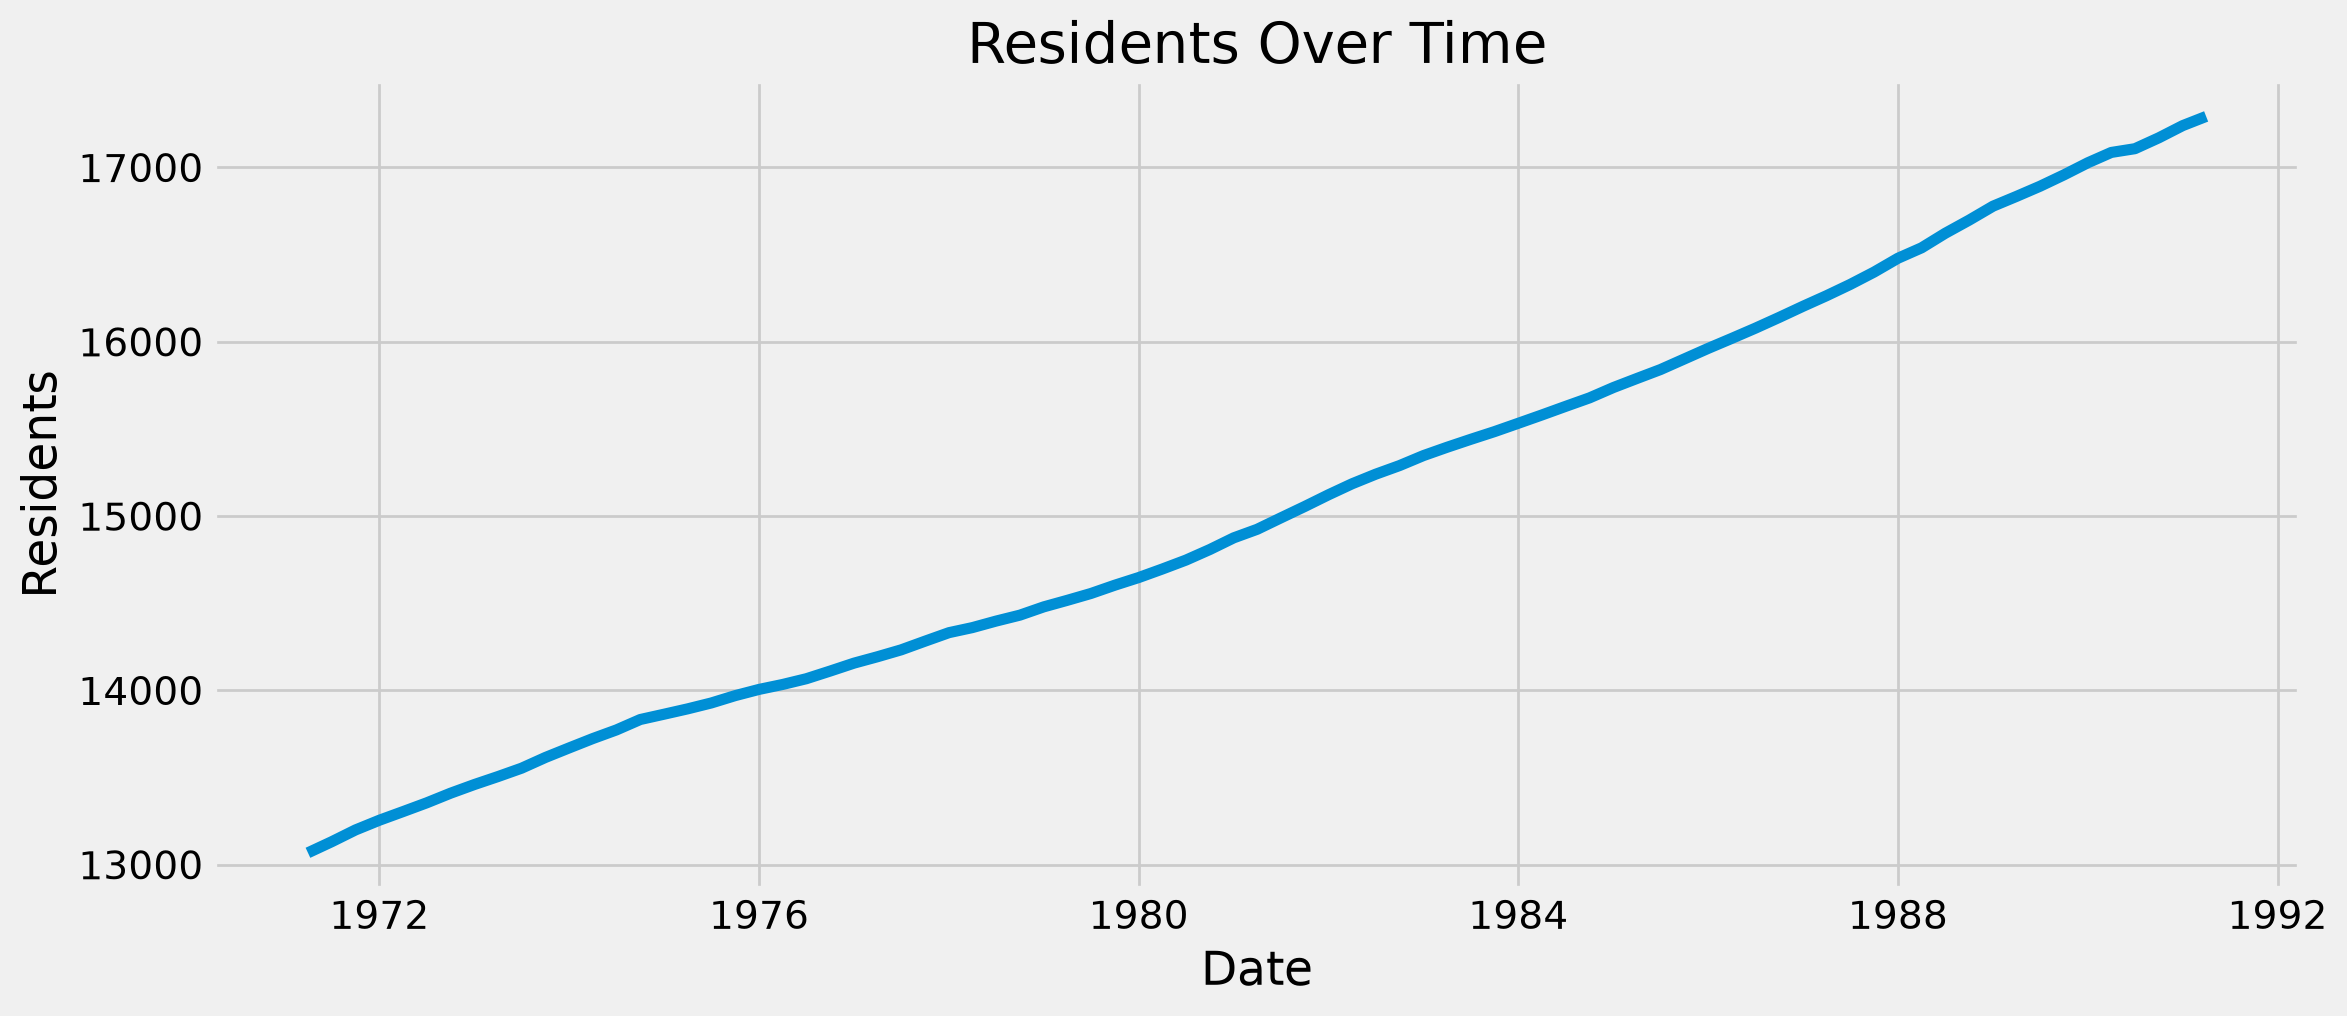

In [16]:
# YOUR CODE HERE
plt.figure(figsize=(12, 5))

plt.plot(df_eda.index, df_eda['residents'])

plt.xlabel('Date')
plt.ylabel('Residents')
plt.title('Residents Over Time')

plt.show()

> Observation: The residents series has a strong upward trend, indicating that the number of residents steadily increases over time. The quarter-to-quarter spread appears roughly constant, with only small variations in the rate of growth.

## Part 2 - Seasonal Decomposition

A time series can be split into three components: **trend**, **seasonal**, and **residual**.

### 4. Decompose `residents` using `seasonal_decompose` (`period=4` since this is quarterly data). Plot the trend, seasonal, and residual components.

In [17]:
print(df.index.freq)

None


In [18]:
df.index.freq = 'QS'

In [19]:
print(df.index.freq)

<QuarterBegin: startingMonth=1>


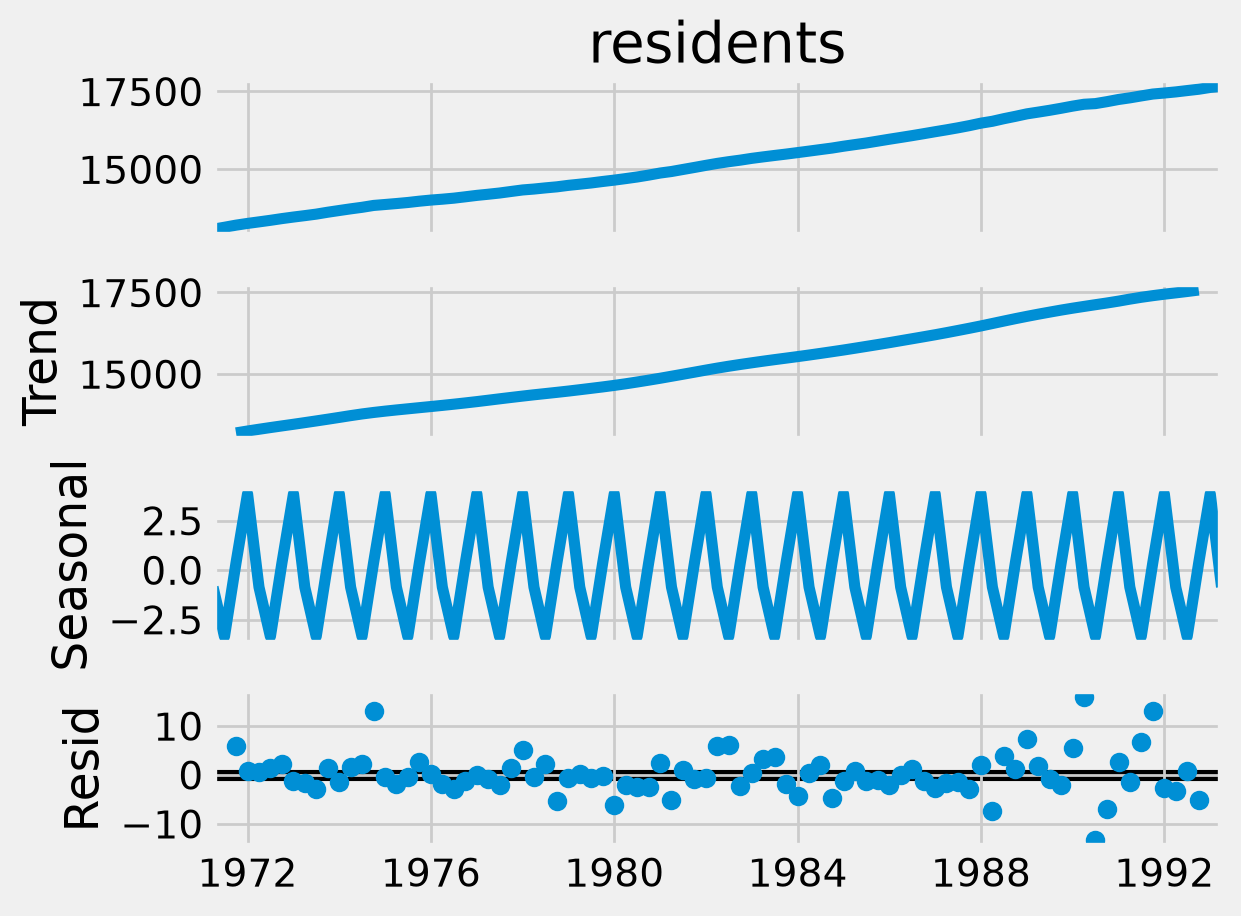

In [20]:
# YOUR CODE HERE
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['residents'],period=4)
result.plot();


## Part 3 - Visualizing Trend with Rolling Mean and Resampling.

With quarterly data, a 4-quarter (1-year) rolling window is the suitable choice, as it averages away any seasonal fluctuations and leaves just the trend.

### 5. Compute and plot a 4-quarter rolling mean of `residents`, overlaid on the raw series.

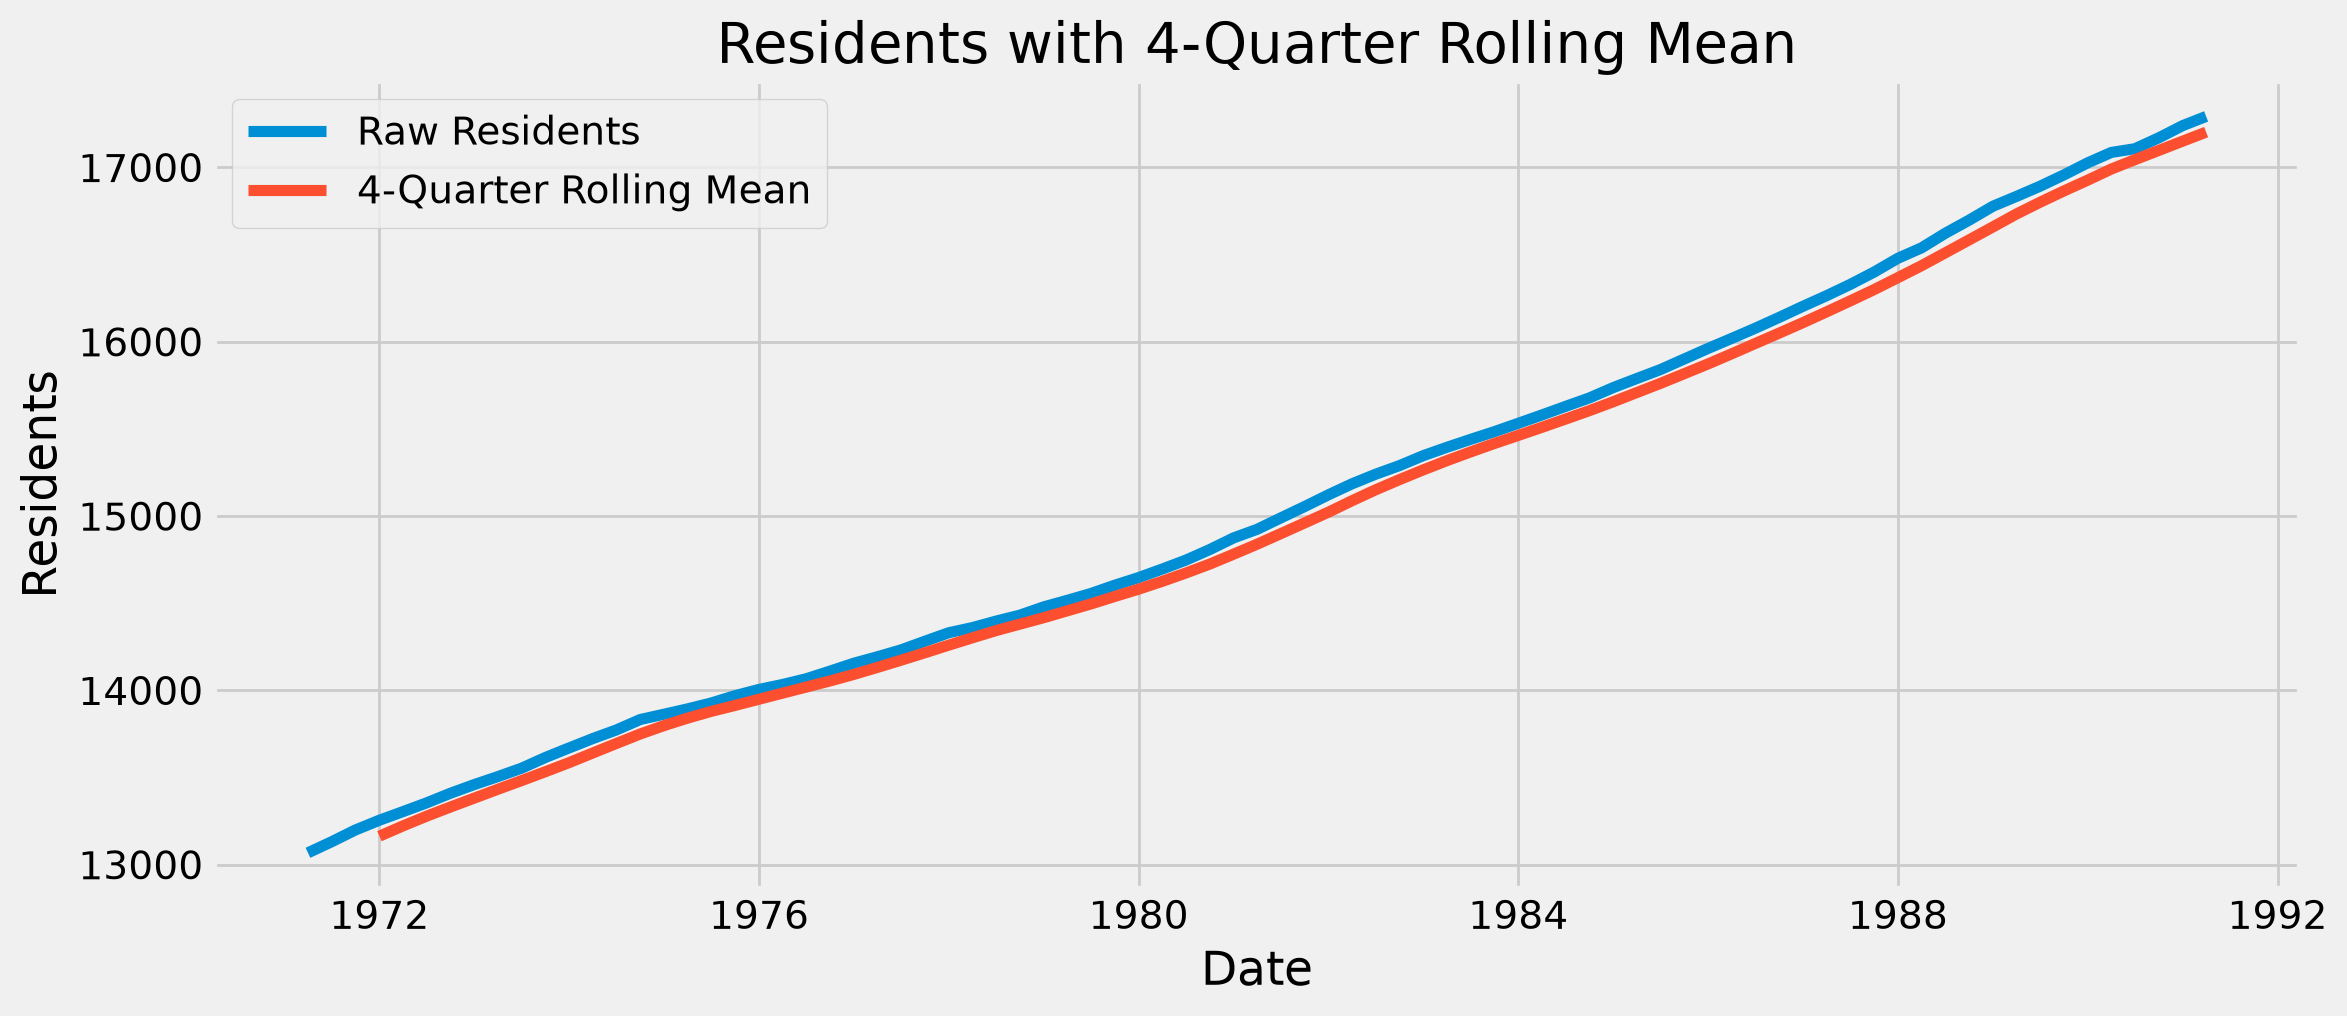

In [28]:
# YOUR CODE HERE
# Calculate 4-quarter rolling mean
rolling_mean = df_eda['residents'].rolling(window=4).mean()

# Plot raw data
plt.figure(figsize=(12, 5))
plt.plot(df_eda.index, df_eda['residents'], label='Raw Residents')

# Plot rolling mean
plt.plot(df_eda.index, # X label
         rolling_mean, # y label
         label='4-Quarter Rolling Mean'
        )

plt.xlabel('Date')
plt.ylabel('Residents')
plt.title('Residents with 4-Quarter Rolling Mean')
plt.legend()
plt.show()

### 6. Plot a 4-quarter rolling standard deviation. Is the spread of fluctuations roughly stable over time, or does it change?

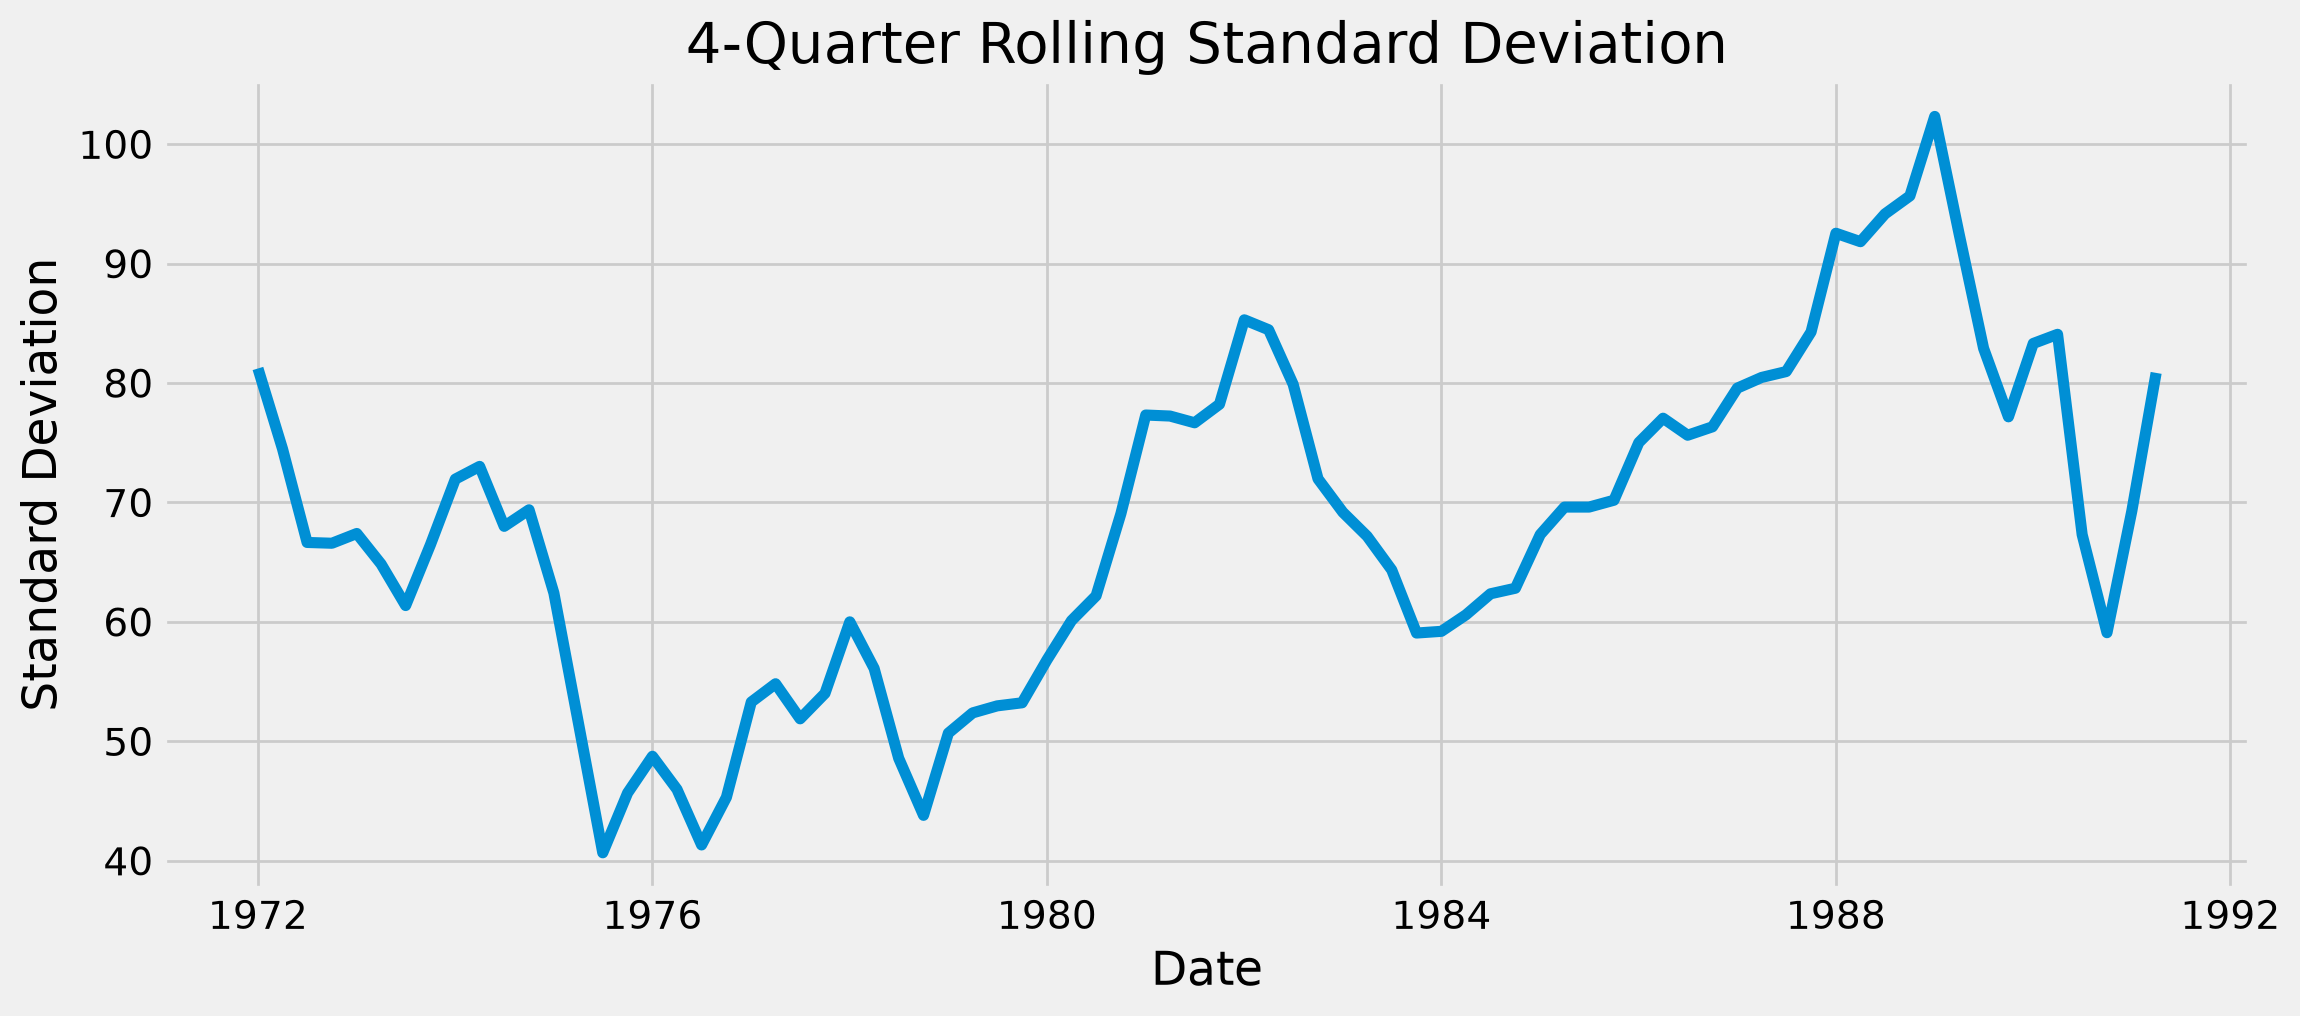

In [29]:
# YOUR CODE HERE
rolling_std = df_eda['residents'].rolling(window=4).std()

plt.figure(figsize=(12, 5))
plt.plot(df_eda.index, rolling_std)

plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.title('4-Quarter Rolling Standard Deviation')
plt.show()

Observation

> The 4-quarter rolling standard deviation changes over time, indicating that the variability in residents is not constant. It decreases during the mid-1970s, then generally increases through the 1980s, reaching its highest level around 1989. Therefore, the quarter-to-quarter spread changes over time rather than remaining roughly stable.

## Part 4 - Stationarity and the ADF Test

A stationary series has a constant mean, variance, and autocorrelation structure over time *(most classical forecasting models assume this)*. We test for it with the **Augmented Dickey-Fuller (ADF) test**:

- **Null hypothesis (H0):** the series has a unit root (i.e. it is *non-stationary*).
- If the p-value is small (typically ≤ 0.05), we reject H0 and conclude the series **is** *stationary*.

### 7. Write an `adf_test()` helper function that runs `adfuller()` and prints the test statistic, p-value, and a plain-English conclusion.

In [32]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    """
    Pass in a time series, and prints an ADF report.
    """
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")    

### 8. Run `adf_test()` on the raw `residents` series. Then apply `.diff()` and run it again. Is one difference enough?

In [34]:
# YOUR CODE HERE
adf_test(df['residents'])


ADF test statistic       0.517268
p-value                  0.985389
# lags used              4.000000
# observations          84.000000
critical value (1%)     -3.510712
critical value (5%)     -2.896616
critical value (10%)    -2.585482
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [35]:
residents_diff = df['residents'].diff()

adf_test(residents_diff)

ADF test statistic      -1.853505
p-value                  0.354240
# lags used              3.000000
# observations          84.000000
critical value (1%)     -3.510712
critical value (5%)     -2.896616
critical value (10%)    -2.585482
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


Observation
> One is not enough

### 9. If the first difference wasn't enough, try a second difference (`.diff().diff()`). Is it stationary now? 
*This will be your `d` term in the modeling stage*.

In [36]:
# YOUR CODE HERE
residents_diff = df['residents'].diff().diff()

adf_test(residents_diff)

ADF test statistic     -8.872347e+00
p-value                 1.387048e-14
# lags used             2.000000e+00
# observations          8.400000e+01
critical value (1%)    -3.510712e+00
critical value (5%)    -2.896616e+00
critical value (10%)   -2.585482e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


Conclusion: 
>After applying the second difference, the residents series is stationary. The ADF test gives a very small p-value, so we reject the null hypothesis of a unit root.

## Part 5 - Autocorrelation and Seasonality

ACF and PACF plots show how correlated a series is with its own past values at different lags. We look at these on the **differenced** series, with the trend removed, any repeating seasonal correlation stands out clearly instead of being buried under the trend's slow decay.

### 10. Plot the ACF and PACF of the series out to at least 20 lags.

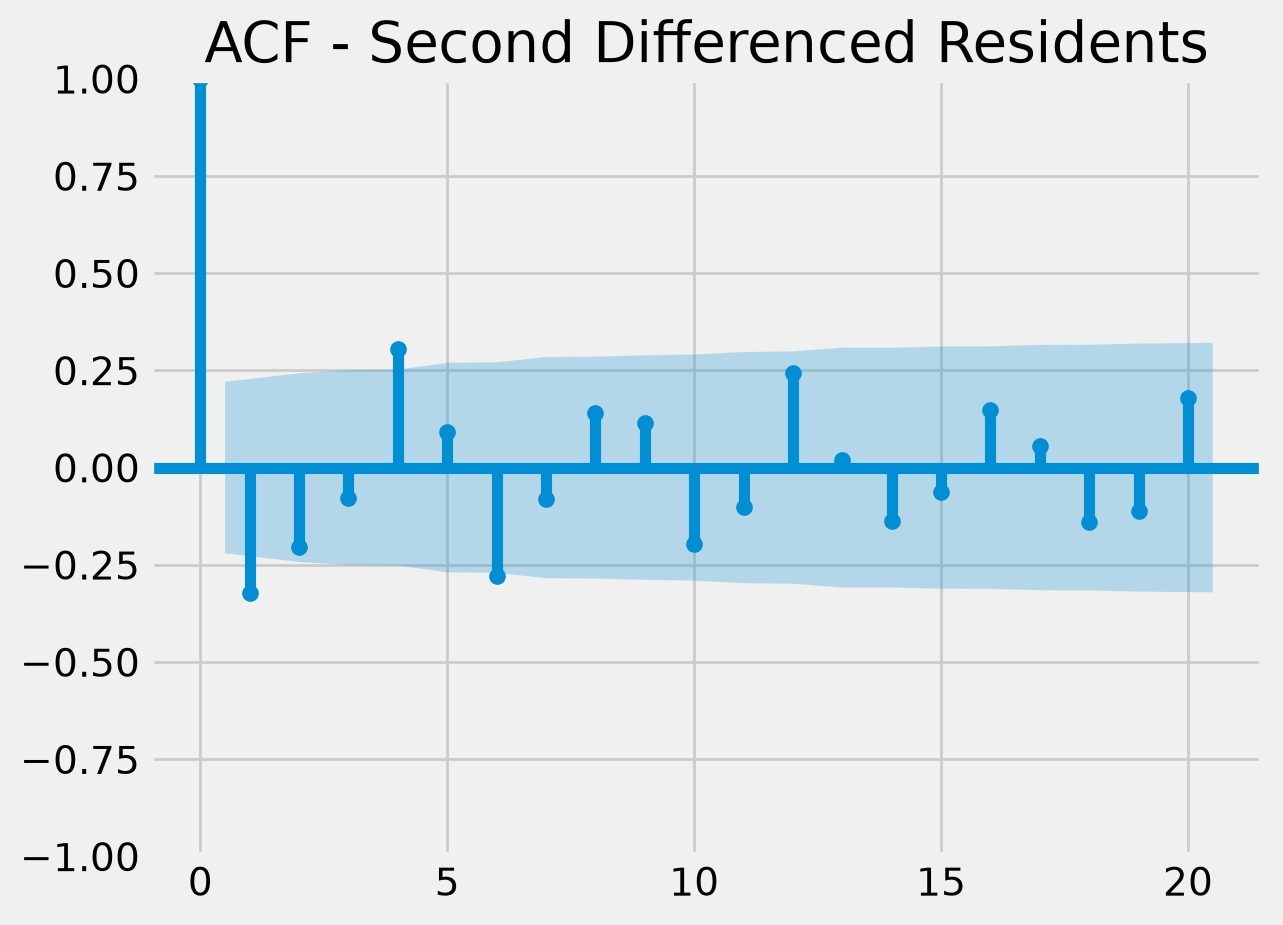

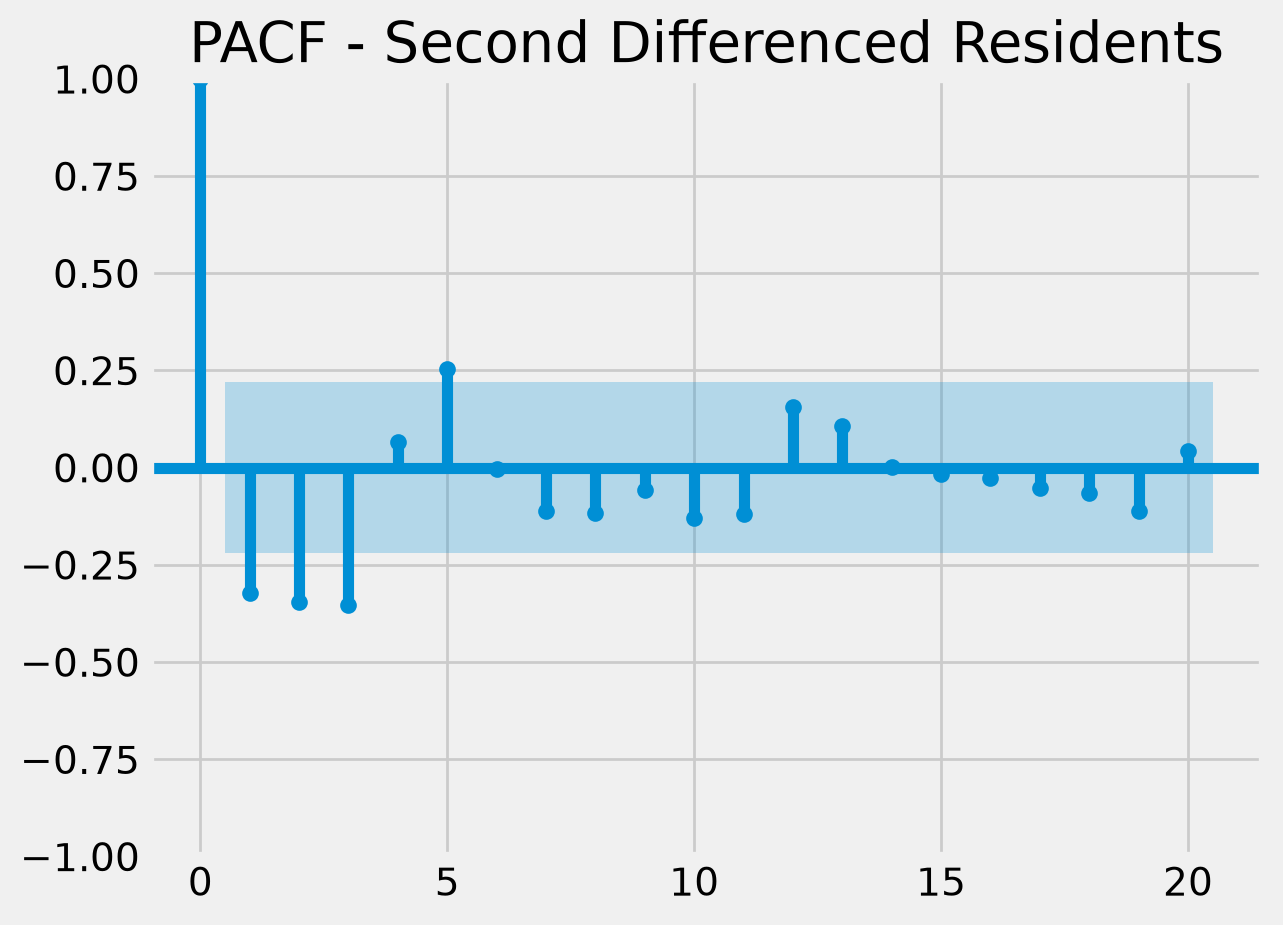

In [37]:
# YOUR CODE HERE
residents_diff = df_eda['residents'].diff().diff()

# Remove NaN values caused by differencing
residents_diff = residents_diff.dropna()

# ACF
plot_acf(residents_diff, lags=20)
plt.title('ACF - Second Differenced Residents')
plt.show()

# PACF
plot_pacf(residents_diff, lags=20)
plt.title('PACF - Second Differenced Residents')
plt.show()

### 11. Look closely at the ACF plot. At which lag do you see the strongest spike? What does that tell you about the data?

Looking at your ACF plot, and ignoring lag 0 because it is always 1, the strongest spike by magnitude occurs at lag 1, with an autocorrelation of approximately −0.32.

The strongest ACF spike occurs at lag 1 and is negative. This indicates that the current quarter has a negative relationship with the immediately previous quarter after second differencing. There is also a noticeable positive spike at lag 4, which may suggest some annual seasonal behavior because the data is quarterly, but the seasonal pattern is not strongly repeated at lags 8, 12, 16, and 20.

So I would not claim strong seasonality from this ACF plot. The clearest autocorrelation is at lag 1.